# 2 - Preprocessing and Modeling

This notebook shows the modeling work directly in notebook cells. The reusable `.py` files mirror this logic for the website and reproducible training.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

TABLES = Path('../reports/tables')
metrics = pd.read_csv(TABLES / 'model_metrics.csv')
feature_selection = pd.read_csv(TABLES / 'feature_selection_importance.csv')
permutation_importance = pd.read_csv(TABLES / 'permutation_importance.csv')
ablation = pd.read_csv(TABLES / 'feature_count_ablation.csv')
errors = pd.read_csv(TABLES / 'highest_test_errors.csv')
seeds = pd.read_csv(TABLES / 'seed_sensitivity.csv')
metrics.head()

              model  train_rows_used     MAE    RMSE    R2    stage                                                    best_params
  Extra Trees Tuned          33397.0 276.075 483.250 0.940    tuned  {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 200}
   Voting Regressor              NaN 277.277 484.170 0.939 ensemble                                                            NaN
 Stacking Regressor              NaN 286.793 487.558 0.939 ensemble                                                            NaN
        Extra Trees          33397.0 283.267 487.588 0.938 baseline                                                            NaN
Random Forest Tuned          33397.0 279.742 489.522 0.938    tuned {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 100}


## Pipeline Summary

The notebook follows the same leakage-safe process used by `run_train.py`.

In [ ]:
pipeline_steps

1. Load CSV, parse date_time, sort chronologically.
2. Remove temp == 0 globally because it is physically invalid.
3. Chronological 70/15/15 train-validation-test split.
4. Fit rainfall cap, rare categories, scaler, outlier detector, and feature selection on train only.
5. Compare baseline models on validation data.
6. Tune top candidates using validation-aware PredefinedSplit.
7. Evaluate Voting and Stacking ensembles.
8. Evaluate final model once on untouched test data.


## Feature Count Ablation

In [ ]:
ablation[['top_k', 'model', 'MAE', 'RMSE', 'R2']]

 top_k                 model     MAE    RMSE    R2
    10 RandomForestRegressor 287.859 497.885 0.936
    15 RandomForestRegressor 338.399 537.737 0.925
    20 RandomForestRegressor 335.354 533.227 0.926
    25 RandomForestRegressor 333.697 531.422 0.927


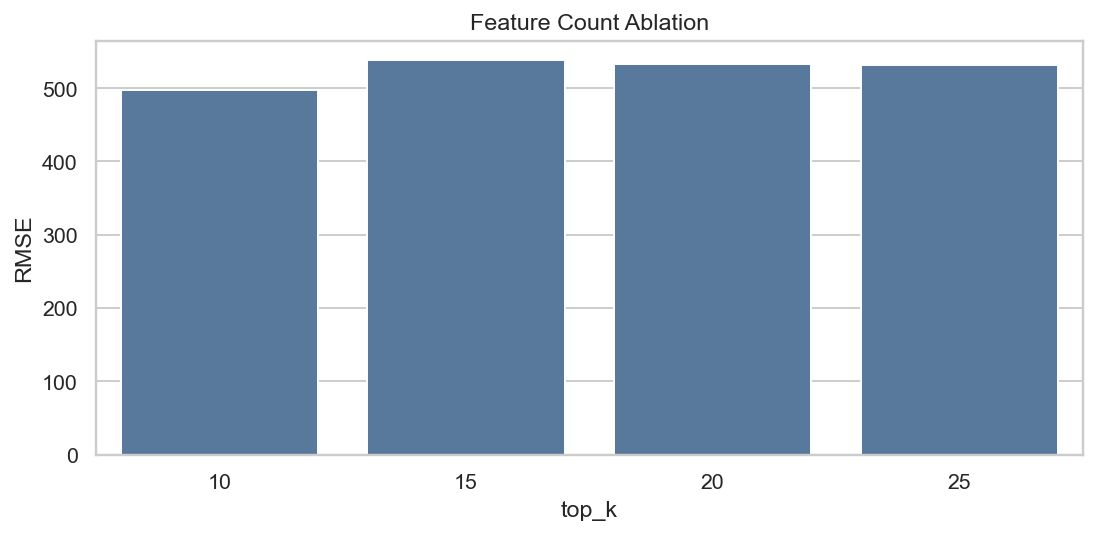

In [ ]:
sns.barplot(data=ablation.sort_values('top_k'), x='top_k', y='RMSE')
plt.title('Feature Count Ablation')
plt.show()

## Selected Features

In [ ]:
selected_features

 rank selected_feature
    1         hour_cos
    2             hour
    3         hour_sin
    4          dow_sin
    5      day_of_week
    6       is_weekend
    7         is_night
    8        month_cos
    9           temp_c
   10             temp


## Random Forest Feature Selection Importance

In [ ]:
feature_selection.head(15)

     feature  importance
    hour_cos      0.6643
        hour      0.1347
    hour_sin      0.0445
     dow_sin      0.0381
 day_of_week      0.0319
  is_weekend      0.0307
    is_night      0.0082
   month_cos      0.0058
      temp_c      0.0057
        temp      0.0057
     temp_c2      0.0057
is_rush_hour      0.0049
        year      0.0049
     dow_cos      0.0045
       month      0.0024


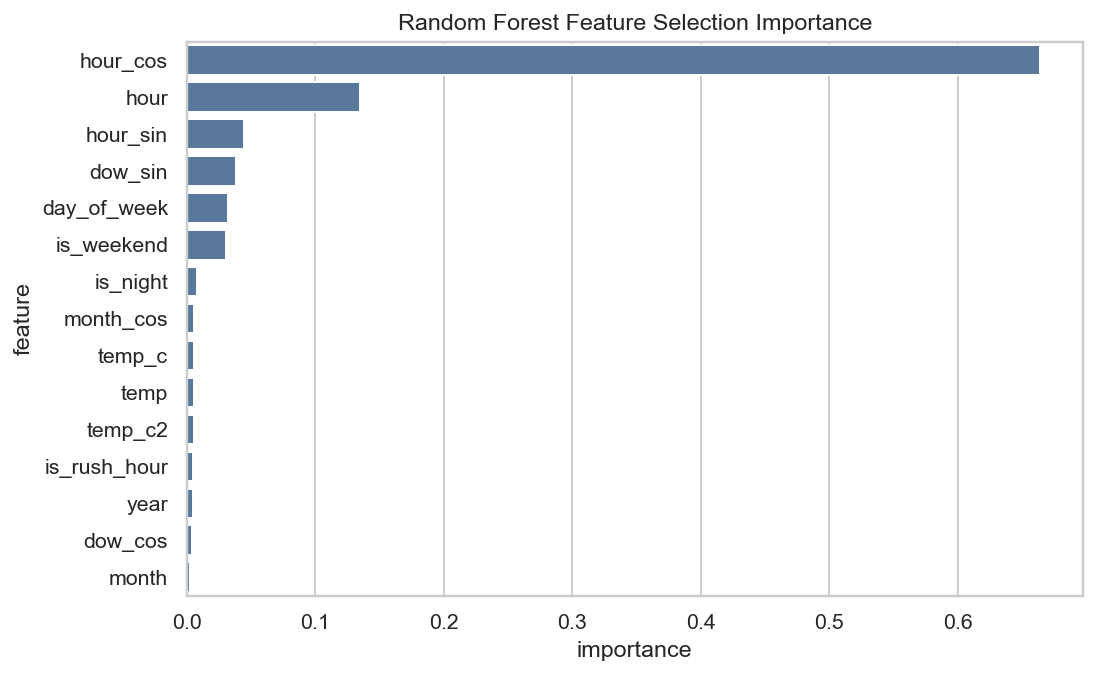

In [ ]:
sns.barplot(data=feature_selection.head(15), y='feature', x='importance')
plt.title('Random Forest Feature Selection Importance')
plt.show()

## Baseline, Tuned, and Ensemble Model Comparison

In [ ]:
metrics

                  model  train_rows_used      MAE     RMSE    R2      stage                                                    best_params
      Extra Trees Tuned          33397.0  276.075  483.250 0.940      tuned  {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 200}
       Voting Regressor              NaN  277.277  484.170 0.939   ensemble                                                            NaN
     Stacking Regressor              NaN  286.793  487.558 0.939   ensemble                                                            NaN
            Extra Trees          33397.0  283.267  487.588 0.938   baseline                                                            NaN
    Random Forest Tuned          33397.0  279.742  489.522 0.938      tuned {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 100}
          Random Forest          33397.0  287.859  497.885 0.936   baseline                                                            NaN
Gradient Boosting Tuned    

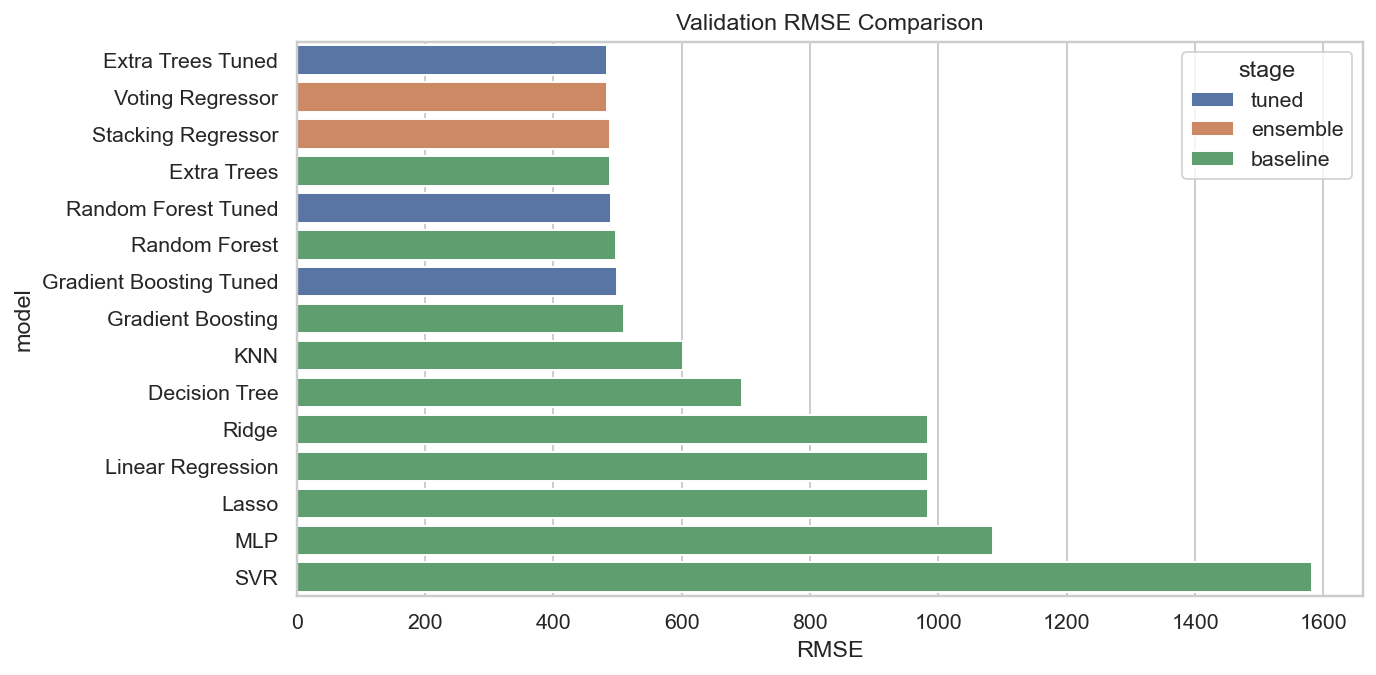

In [ ]:
plot_df = metrics[metrics['stage'].isin(['baseline', 'tuned', 'ensemble'])].sort_values('RMSE')
sns.barplot(data=plot_df, y='model', x='RMSE', hue='stage', dodge=False)
plt.title('Validation RMSE Comparison')
plt.show()

## Hyperparameter Tuning Results

In [ ]:
tuned_results

                  model  train_rows_used     MAE    RMSE    R2                                                    best_params
      Extra Trees Tuned          33397.0 276.075 483.250 0.940  {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 200}
    Random Forest Tuned          33397.0 279.742 489.522 0.938 {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 100}
Gradient Boosting Tuned          33397.0 297.332 499.311 0.936    {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


## Ensemble Results

In [ ]:
ensemble_results

             model     MAE    RMSE    R2
  Voting Regressor 277.277 484.170 0.939
Stacking Regressor 286.793 487.558 0.939


## Final Test Evaluation

In [ ]:
final_test

            model     MAE    RMSE   R2
Extra Trees Tuned 261.911 485.846 0.94


## Permutation Importance

In [ ]:
permutation_importance

    feature  importance_mean  importance_std
   is_night        1055.0255          6.1762
   hour_cos         637.8531          3.0808
 is_weekend         518.6742         12.0526
       hour         294.7617          3.8351
   hour_sin         147.0861          3.2543
  month_cos          54.7113          1.9617
day_of_week          49.5936          2.1003
    dow_sin          34.6302          2.2033
       temp          10.6514          1.6229
     temp_c           8.6813          1.4740


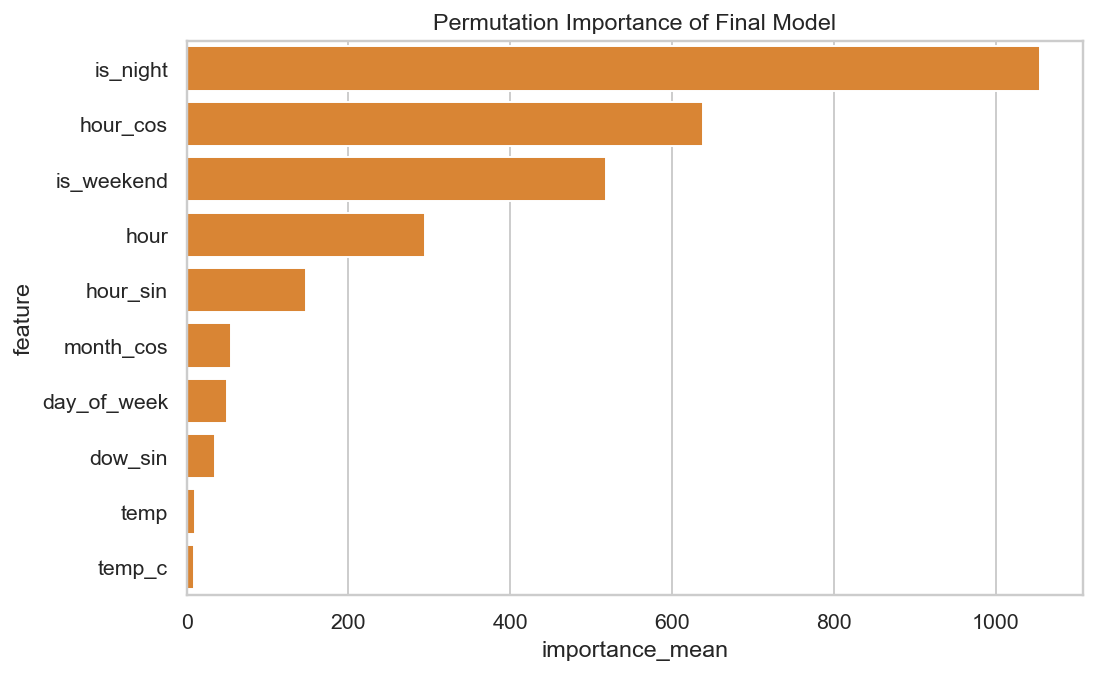

In [ ]:
sns.barplot(data=permutation_importance.head(10), y='feature', x='importance_mean')
plt.title('Permutation Importance of Final Model')
plt.show()

## Error Analysis

In [ ]:
highest_test_errors.head(10)

          date_time  actual  predicted    error  absolute_error  hour  month
2018-07-04 07:00:00    1128    6160.94 -5032.94         5032.94     7      7
2018-05-28 07:00:00     989    5900.94 -4911.94         4911.94     7      5
2018-07-04 06:00:00    1141    5689.86 -4548.86         4548.86     6      7
2018-07-04 08:00:00    1275    5681.72 -4406.72         4406.72     8      7
2018-05-28 06:00:00     882    5272.30 -4390.30         4390.30     6      5
2018-05-28 08:00:00    1294    5461.21 -4167.21         4167.21     8      5
2018-09-03 07:00:00    1556    5505.00 -3949.00         3949.00     7      9
2018-09-03 07:00:00    1556    5505.00 -3949.00         3949.00     7      9
2018-03-05 17:00:00    1953    5829.39 -3876.39         3876.39    17      3
2018-03-05 17:00:00    1953    5829.39 -3876.39         3876.39    17      3


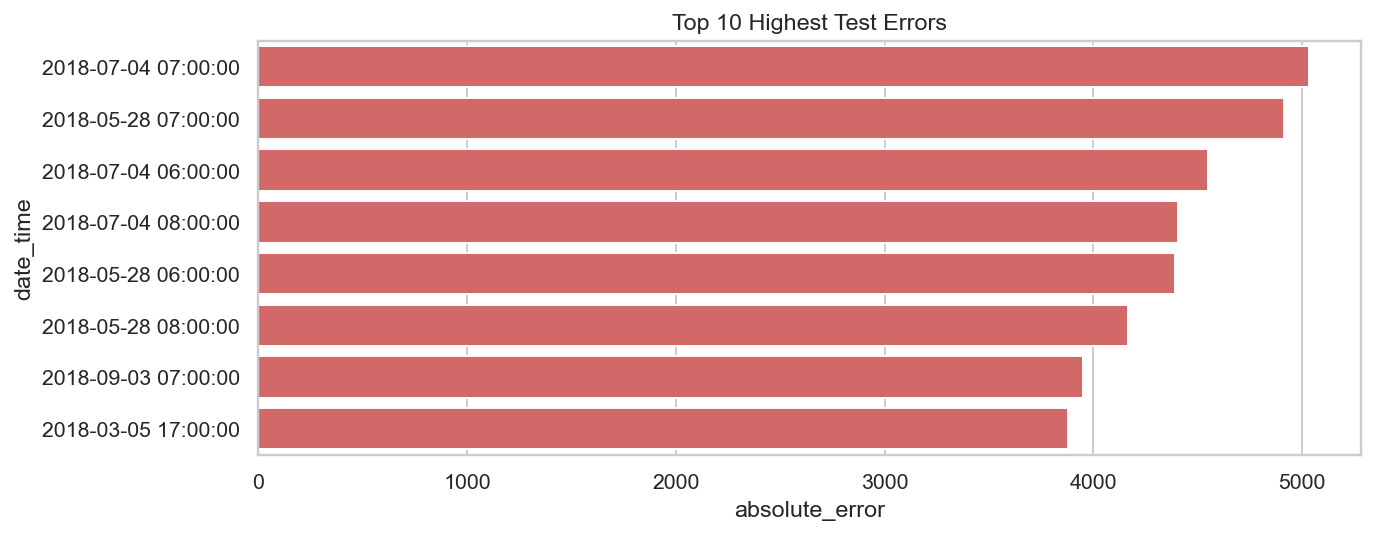

In [ ]:
errors['date_time'] = pd.to_datetime(errors['date_time'])
sns.barplot(data=errors.head(10), x='absolute_error', y='date_time')
plt.title('Top 10 Highest Test Errors')
plt.show()

## Seed Sensitivity

In [ ]:
seed_sensitivity

        model  seed     MAE    RMSE    R2
Random Forest     7 287.995 497.838 0.936
Random Forest    42 287.859 497.885 0.936
Random Forest    99 288.150 499.168 0.936


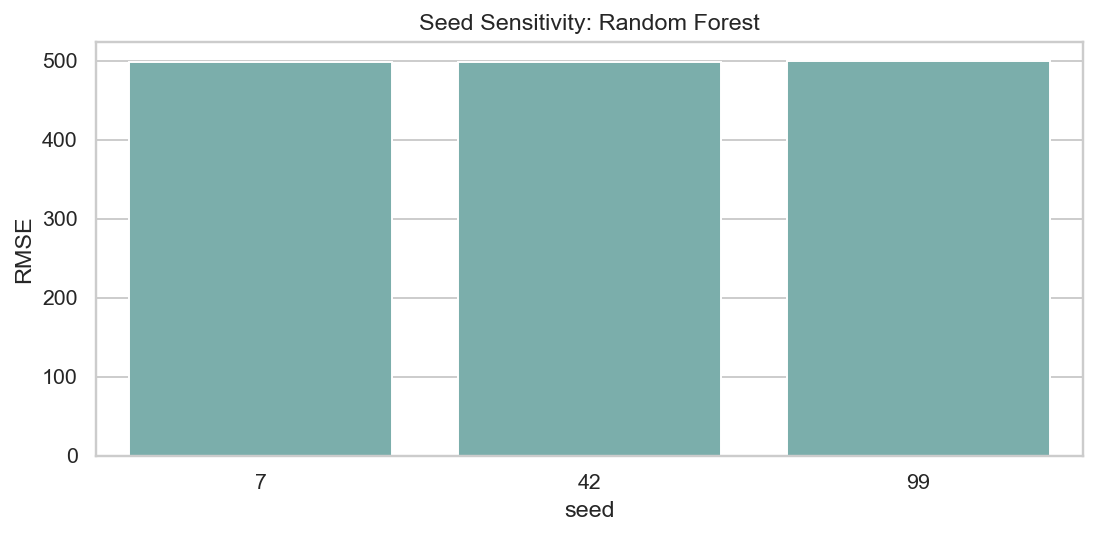

In [ ]:
sns.barplot(data=seeds, x='seed', y='RMSE')
plt.title('Seed Sensitivity: Random Forest')
plt.show()